# Confusion matrices

Where each spam filter goes wrong, on both datasets from the experiment described in the
[README](../README.md): the 18,514 unique emails in email-dataset and the 2,876 unique messages in
Ling-Spam. A message counts as spam when its score is at or above `CUTOFF` (0.5 in the README;
change it below to see how the matrices shift).

The scores come from `results/tfidf_oof.jsonl` and `results/lingspam_tfidf_oof.jsonl`, written by
`tfidf_baseline.py`. They have one row per unique message with every approach's score, so this
notebook needs neither dataset nor an API key.

The Ling-Spam corpus was created by I. Androutsopoulos, J. Koutsias, K.V. Chandrinos, G. Paliouras
and C.D. Spyropoulos ("An Evaluation of Naive Bayesian Anti-Spam Filtering", ECML 2000 workshop).
Thanks to them for making it available.

In [1]:
import json
import math
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
from matplotlib.patches import Rectangle

CUTOFF = 0.5  # a message counts as spam when its score is at least this

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent

# For each dataset: its scores file, and README name -> (column in that file, labeled messages used).
# "compare" names the TypeSafe question set against logistic regression in the agreement chart.
DATASETS = {
    "email-dataset": {
        "file": "tfidf_oof.jsonl",
        "unit": "emails",
        "approaches": {
            "TypeSafe, plain question": ("TypeSafe: bare question (0 labels)", "0 labeled emails"),
            "TypeSafe, detailed criteria": ("TypeSafe: structured criteria (0 labels)", "0 labeled emails"),
            "TF-IDF logistic regression": ("TF-IDF logreg, grouped CV (~14.8K labels)", "~14.8K labeled emails"),
            "TF-IDF naive Bayes": ("TF-IDF naive Bayes, grouped CV", "~14.8K labeled emails"),
            "Average of detailed criteria and logistic regression": (
                "Average of structured criteria + logreg", "~14.8K labeled emails"),
        },
        "compare": "TypeSafe, detailed criteria",
    },
    "Ling-Spam": {
        "file": "lingspam_tfidf_oof.jsonl",
        "unit": "messages",
        "approaches": {
            "TypeSafe, plain question": ("TypeSafe: bare question (0 labels)", "0 labeled messages"),
            "TypeSafe, detailed criteria": ("TypeSafe: structured criteria (0 labels)", "0 labeled messages"),
            "TF-IDF logistic regression": ("TF-IDF logreg, grouped CV (~2.3K labels)", "~2.3K labeled messages"),
            "TF-IDF naive Bayes": ("TF-IDF naive Bayes, grouped CV", "~2.3K labeled messages"),
            "Average of detailed criteria and logistic regression": (
                "Average of structured criteria + logreg", "~2.3K labeled messages"),
        },
        "compare": "TypeSafe, plain question",
    },
}

## Shared code

Loading, counting and drawing are the same for both datasets. In the heatmaps only mistakes are
colored, on one blue scale shared by every matrix of a dataset, so a darker cell always means more
wrong messages. Correct predictions are gray. Each dataset has its own scale, shown in its key.

In [2]:
def load(dataset):
    """Labels and every approach's scores for a dataset."""
    config = DATASETS[dataset]
    rows = [json.loads(line) for line in (ROOT / "results" / config["file"]).open()]
    is_spam = np.array([row["label"] == "spam" for row in rows])
    scores = {name: np.array([row[column] for row in rows]) for name, (column, _) in config["approaches"].items()}
    print(f"{dataset}: {len(rows):,} {config['unit']}, {(~is_spam).sum():,} ham, {is_spam.sum():,} spam")
    return is_spam, scores


def confusion(is_spam, score):
    """2x2 counts: rows are the true label (ham, spam), columns the prediction (ham, spam)."""
    predicted_spam = score >= CUTOFF
    return np.array([
        [np.sum(~is_spam & ~predicted_spam), np.sum(~is_spam & predicted_spam)],
        [np.sum(is_spam & ~predicted_spam), np.sum(is_spam & predicted_spam)],
    ])


def show_table(matrices):
    table = [
        "| Approach | Correct ham | Ham flagged as spam | Missed spam | Correct spam | Accuracy |",
        "|---|---|---|---|---|---|",
    ]
    for name, m in matrices.items():
        table.append(
            f"| {name} | {m[0, 0]:,} | {m[0, 1]:,} ({m[0, 1] / m[0].sum():.2%}) "
            f"| {m[1, 0]:,} ({m[1, 0] / m[1].sum():.2%}) | {m[1, 1]:,} | {np.trace(m) / m.sum():.2%} |"
        )
    display(Markdown("\n".join(table)))


def agreement(is_spam, typesafe_score, logreg_score):
    """Per true label, 2x2 counts with rows TypeSafe's call (ham, spam) and columns logreg's call."""
    typesafe_says_spam, logreg_says_spam = typesafe_score >= CUTOFF, logreg_score >= CUTOFF
    counts = {}
    for label, true_spam in (("Actual ham", False), ("Actual spam", True)):
        in_class = is_spam == true_spam
        counts[label] = np.array([
            [np.sum(in_class & (typesafe_says_spam == ts) & (logreg_says_spam == lr)) for lr in (False, True)]
            for ts in (False, True)
        ])
    typesafe_right, logreg_right = typesafe_says_spam == is_spam, logreg_says_spam == is_spam
    print(f"both right:          {np.sum(typesafe_right & logreg_right):,}")
    print(f"only TypeSafe right: {np.sum(typesafe_right & ~logreg_right):,}")
    print(f"only logreg right:   {np.sum(~typesafe_right & logreg_right):,}")
    print(f"both wrong:          {np.sum(~typesafe_right & ~logreg_right):,}")
    return counts

In [3]:
RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
        "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
NEUTRAL, INK, INK_2, SURFACE = "#f0efec", "#0b0b0b", "#52514e", "#fcfcfb"
MISTAKES = LinearSegmentedColormap.from_list("mistakes", RAMP)


def mistake_scale(matrices, agreements):
    """A 0-to-round-number scale covering every mistake cell in a dataset's charts."""
    counts = [m[0, 1] for m in matrices.values()] + [m[1, 0] for m in matrices.values()]
    counts += [m[0, 1] for m in agreements.values()] + [m[1, 0] for m in agreements.values()]
    counts += [agreements["Actual ham"][1, 1], agreements["Actual spam"][0, 0]]
    top = max(max(counts), 1)
    step = 10 ** math.floor(math.log10(top))
    return Normalize(0, math.ceil(top / step) * step)


def luminance(color):
    channels = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in to_rgb(color)]
    return 0.2126 * channels[0] + 0.7152 * channels[1] + 0.0722 * channels[2]


def ink_on(fill):
    """White or near-black text, whichever contrasts more with the fill."""
    white = 1.05 / (luminance(fill) + 0.05)
    dark = (luminance(fill) + 0.05) / (luminance(INK) + 0.05)
    return "white" if white > dark else INK


def draw_matrix(ax, counts, correct, row_labels, col_labels, notes, title, norm):
    gap = 0.025
    ax.set_facecolor(SURFACE)
    for r in range(2):
        for c in range(2):
            fill = NEUTRAL if correct[r][c] else MISTAKES(norm(counts[r, c]))
            ax.add_patch(Rectangle((c + gap, r + gap), 1 - 2 * gap, 1 - 2 * gap, facecolor=fill, edgecolor="none"))
            color = INK if correct[r][c] else ink_on(fill)
            ax.text(c + 0.08, r + 0.42, f"{counts[r, c]:,}", fontsize=15, fontweight="bold", color=color, va="center")
            ax.text(c + 0.08, r + 0.7, notes[r][c], fontsize=9, color=color, va="center")
    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)
    ax.set_xticks([0.5, 1.5], col_labels)
    ax.set_yticks([0.5, 1.5], row_labels)
    ax.xaxis.tick_top()
    ax.tick_params(length=0, labelsize=9, labelcolor=INK_2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, loc="left", fontsize=10.5, color=INK, pad=28)


def add_scale_key(ax, norm, unit):
    ax.axis("off")
    bar = ax.inset_axes([0.05, 0.55, 0.85, 0.08])
    colorbar = plt.colorbar(ScalarMappable(norm, MISTAKES), cax=bar, orientation="horizontal")
    colorbar.outline.set_visible(False)
    colorbar.ax.tick_params(labelsize=9, labelcolor=INK_2, length=3, color=INK_2)
    ax.text(0.05, 0.72, f"Mistakes ({unit})", fontsize=10, color=INK, transform=ax.transAxes)
    ax.add_patch(Rectangle((0.05, 0.25), 0.08, 0.06, facecolor=NEUTRAL, edgecolor="none", transform=ax.transAxes))
    ax.text(0.16, 0.28, "Correct predictions", fontsize=10, color=INK, va="center", transform=ax.transAxes)


def plot_confusions(dataset, is_spam, matrices, norm):
    config = DATASETS[dataset]
    n_ham, n_spam = int((~is_spam).sum()), int(is_spam.sum())
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), facecolor=SURFACE, layout="constrained")
    slots = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1], axes[1, 2]]
    for ax, (name, m) in zip(slots, matrices.items()):
        notes = [[f"{m[0, 0] / n_ham:.2%} of ham", f"{m[0, 1] / n_ham:.2%} of ham"],
                 [f"{m[1, 0] / n_spam:.2%} of spam", f"{m[1, 1] / n_spam:.2%} of spam"]]
        title = f"{textwrap.fill(name, 34)}\n{config['approaches'][name][1]} · {np.trace(m) / m.sum():.2%} accurate"
        draw_matrix(ax, m, [[True, False], [False, True]], [f"Actual ham\n{n_ham:,}", f"Actual spam\n{n_spam:,}"],
                    ["Predicted ham", "Predicted spam"], notes, title, norm)
    add_scale_key(axes[0, 2], norm, config["unit"])
    fig.suptitle(f"{dataset}: confusion matrices at cutoff {CUTOFF}", x=0.01, ha="left", fontsize=13, color=INK)
    plt.show()


def kind(typesafe_ok, logreg_ok):
    if typesafe_ok and logreg_ok:
        return "both right"
    if typesafe_ok:
        return "only TypeSafe right"
    return "only logreg right" if logreg_ok else "both wrong"


def plot_agreement(dataset, agreements, norm):
    config = DATASETS[dataset]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), facecolor=SURFACE, layout="constrained")
    for ax, (label, m) in zip(axes, agreements.items()):
        right = 1 if label == "Actual spam" else 0  # index of the correct call
        total = m.sum()
        notes = [[f"{kind(r == right, c == right)} · {m[r, c] / total:.2%}" for c in range(2)] for r in range(2)]
        correct = [[r == right and c == right for c in range(2)] for r in range(2)]
        draw_matrix(ax, m, correct, ["TypeSafe\nsays ham", "TypeSafe\nsays spam"],
                    ["Logreg says ham", "Logreg says spam"], notes, f"{label} ({total:,} {config['unit']})", norm)
    compared = config["compare"].removeprefix("TypeSafe, ")
    fig.suptitle(f"{dataset}: TypeSafe ({compared}) vs TF-IDF logistic regression",
                 x=0.01, ha="left", fontsize=13, color=INK)
    plt.show()

## email-dataset

18,514 unique emails. The agreement chart compares TypeSafe with detailed criteria, the best TypeSafe
question on this dataset, against logistic regression.

In [4]:
email_is_spam, email_scores = load("email-dataset")
email_matrices = {name: confusion(email_is_spam, score) for name, score in email_scores.items()}
show_table(email_matrices)

email-dataset: 18,514 emails, 10,415 ham, 8,099 spam


| Approach | Correct ham | Ham flagged as spam | Missed spam | Correct spam | Accuracy |
|---|---|---|---|---|---|
| TypeSafe, plain question | 9,721 | 694 (6.66%) | 54 (0.67%) | 8,045 | 95.96% |
| TypeSafe, detailed criteria | 10,212 | 203 (1.95%) | 106 (1.31%) | 7,993 | 98.33% |
| TF-IDF logistic regression | 10,265 | 150 (1.44%) | 149 (1.84%) | 7,950 | 98.39% |
| TF-IDF naive Bayes | 10,240 | 175 (1.68%) | 367 (4.53%) | 7,732 | 97.07% |
| Average of detailed criteria and logistic regression | 10,340 | 75 (0.72%) | 69 (0.85%) | 8,030 | 99.22% |

In [5]:
email_agreement = agreement(
    email_is_spam, email_scores[DATASETS["email-dataset"]["compare"]], email_scores["TF-IDF logistic regression"])
email_norm = mistake_scale(email_matrices, email_agreement)

both right:          17,977
only TypeSafe right: 228
only logreg right:   238
both wrong:          71


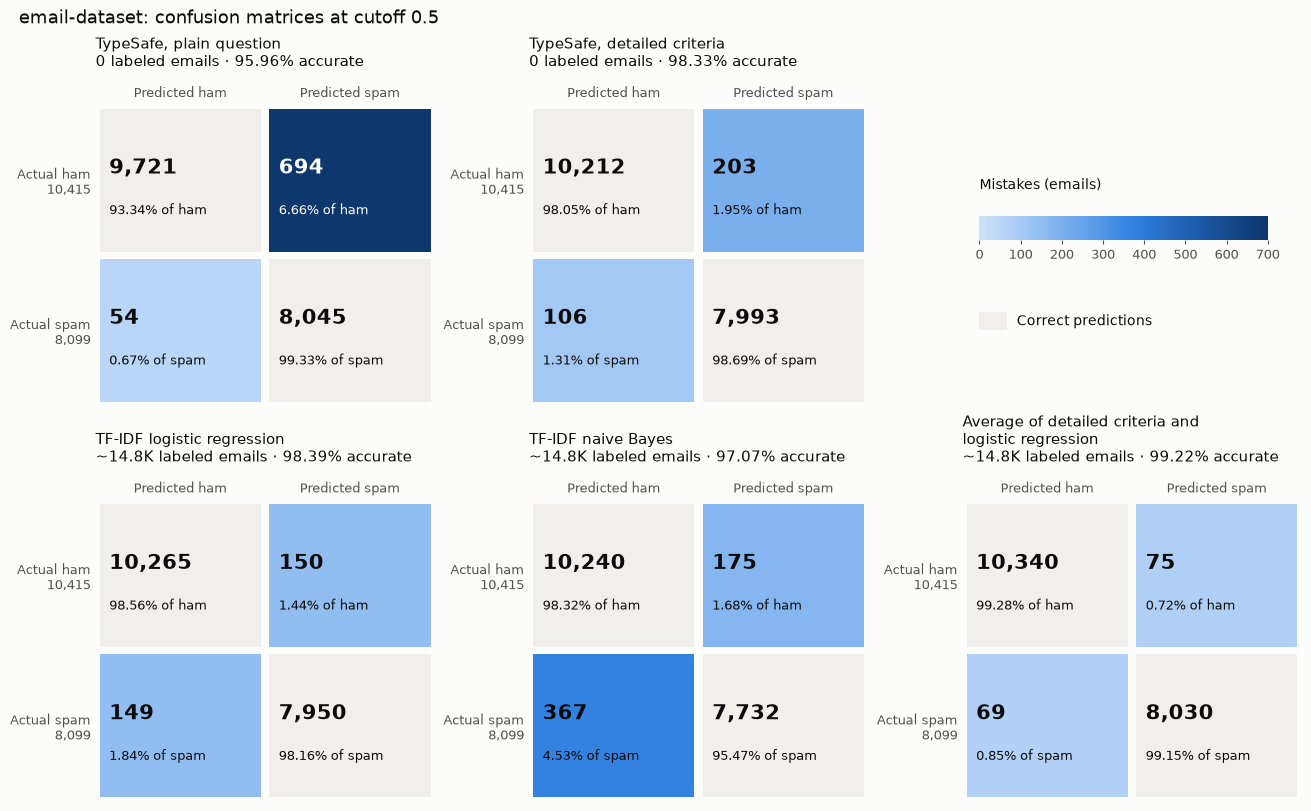

In [6]:
plot_confusions("email-dataset", email_is_spam, email_matrices, email_norm)

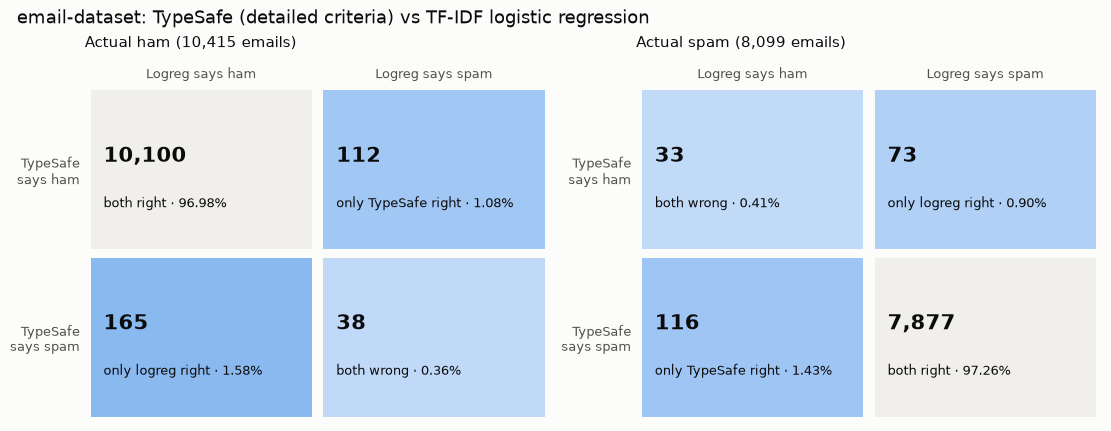

In [7]:
plot_agreement("email-dataset", email_agreement, email_norm)

## Ling-Spam

2,876 unique messages: legitimate posts from the Linguist mailing list and spam. The questions were
the same ones used on email-dataset, unchanged. Here the plain question did best, so the agreement
chart compares it against logistic regression. The color scale is this dataset's own, so compare
shades within this section only.

In [8]:
lingspam_is_spam, lingspam_scores = load("Ling-Spam")
lingspam_matrices = {name: confusion(lingspam_is_spam, score) for name, score in lingspam_scores.items()}
show_table(lingspam_matrices)

Ling-Spam: 2,876 messages, 2,408 ham, 468 spam


| Approach | Correct ham | Ham flagged as spam | Missed spam | Correct spam | Accuracy |
|---|---|---|---|---|---|
| TypeSafe, plain question | 2,369 | 39 (1.62%) | 2 (0.43%) | 466 | 98.57% |
| TypeSafe, detailed criteria | 2,330 | 78 (3.24%) | 8 (1.71%) | 460 | 97.01% |
| TF-IDF logistic regression | 2,407 | 1 (0.04%) | 40 (8.55%) | 428 | 98.57% |
| TF-IDF naive Bayes | 2,405 | 3 (0.12%) | 14 (2.99%) | 454 | 99.41% |
| Average of detailed criteria and logistic regression | 2,407 | 1 (0.04%) | 4 (0.85%) | 464 | 99.83% |

In [9]:
lingspam_agreement = agreement(
    lingspam_is_spam, lingspam_scores[DATASETS["Ling-Spam"]["compare"]], lingspam_scores["TF-IDF logistic regression"])
lingspam_norm = mistake_scale(lingspam_matrices, lingspam_agreement)

both right:          2,796
only TypeSafe right: 39
only logreg right:   39
both wrong:          2


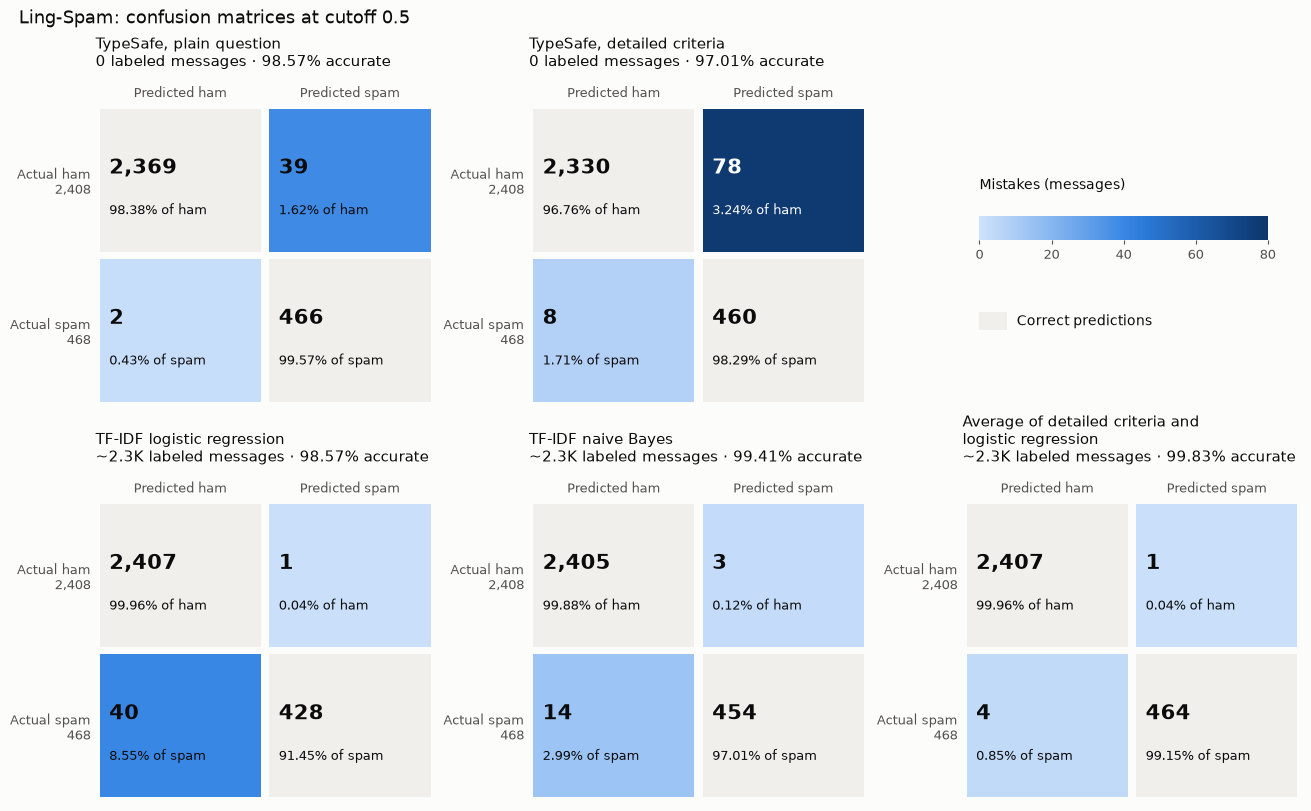

In [10]:
plot_confusions("Ling-Spam", lingspam_is_spam, lingspam_matrices, lingspam_norm)

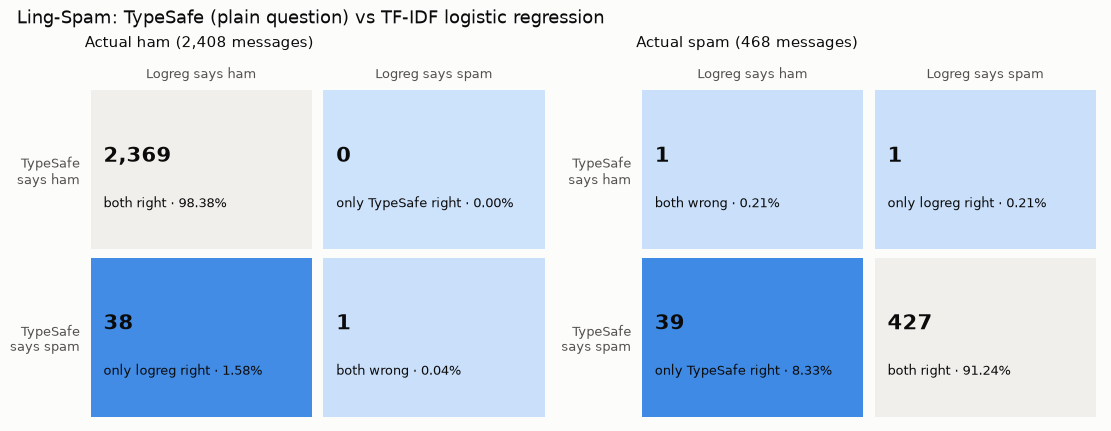

In [11]:
plot_agreement("Ling-Spam", lingspam_agreement, lingspam_norm)